#### 7.5 批量规范化
**批量规范化（Batch Normalization）**，目的是持续加速深层网络的收敛。
##### 7.5.1 训练深层网络
训练神经网络的实际挑战：
- 数据预处理会对结果产生巨大影响；
- 典型多层感知机或卷积神经网络在训练时，中间层的变量变化范围过于广泛；
- 更深层的网络更复杂，更容易过拟合。

只有使用足够大的小批量，批量规范化这种才是有效稳定的。用$\mathbf{x}\in B$表示一个来自小批量$B$的输入，批量规范化$BN$：
$$BN(\mathbf{x})=\gamma\odot\frac{\mathbf{x}-\hat{\mathbf{\mu}}_B}{\hat{\mathbf{\sigma}}_B}+\beta$$
其中，$\hat{\mathbf{\mu}}_B$是小批量$B$的样本均值，$\hat{\mathbf{\sigma}}_B$是小批量$B$的样本标准差。应用标准化后，生成的小批量的均值为0，单位方差为1。使用拉伸参数（Scale Parameter）$\gamma$和偏移参数（Shift Parameter）$\beta$，形状与$\mathbf{X}$相同。
$$\hat{\mathbf{\mu}}_B=\frac{1}{|B|}\sum_{x\in B}x$$
$$\hat{\mathbf{\sigma}}_B^2=\frac{1}{|B|}\sum_{x\in B}(x-\hat{\mathbf{\mu}}_B^2)$$

##### 7.5.2 批量规范化层
批量规范化在完整的小批量上执行，不能忽略批量大小。
1. 全连接层
全连接层输出计算：
$$\mathbf{h}=\phi(BN(\mathbf{W}x+b))$$
2. 卷积层
对于卷积层可以在卷积层之后和激活函数之前应用批量规范化。例如，对于一个包含m个样本的小批量，高度p和宽度q的小批量，对于卷积层在每个输出通道的$m\cdot p\cdot q$个元素上同时执行每个批量规范化，在每个空间位置上执行批量规范化。
3. 预测过程中的批量规范化

##### 7.5.3 从零实现

In [13]:
import torch
from torch import nn
from d2l import torch as d2l

def batch_norm(X, gamma, beta, moving_mean, moving_var, eps, momentum):
    # 通过is_grad_enabled来判断当前模式是训练模式还是预测模式
    if not torch.is_grad_enabled():
        # 如果是在预测模式下，直接使用传入的移动平均所得的均值和方差
        X_hat = (X - moving_mean) / torch.sqrt(moving_var + eps)
    else:
        assert len(X.shape) in (2, 4)
        if len(X.shape) == 2:
            # 使用全连接层的情况，计算特征维上的均值和方差
            mean = X.mean(dim=0)
            var = ((X - mean) ** 2).mean(dim=0)
        else:
            # 使用二维卷积层的情况，计算通道维上（axis=1）的均值和方差。
            # 这里我们需要保持X的形状以便后面可以做广播运算
            mean = X.mean(dim=(0, 2, 3), keepdim=True)
            var = ((X - mean) ** 2).mean(dim=(0, 2, 3), keepdim=True)
        # 训练模式下，用当前的均值和方差做标准化
        X_hat = (X - mean) / torch.sqrt(var + eps)
        # 更新移动平均的均值和方差
        moving_mean = momentum * moving_mean + (1.0 - momentum) * mean
        moving_var = momentum * moving_var + (1.0 - momentum) * var
    Y = gamma * X_hat + beta  # 缩放和移位
    return Y, moving_mean.data, moving_var.data

In [14]:
class BatchNorm(nn.Module):
    # num_features：完全连接层的输出数量或卷积层的输出通道数。
    # num_dims：2表示完全连接层，4表示卷积层
    def __init__(self, num_features, num_dims):
        super().__init__()
        if num_dims == 2:
            shape = (1, num_features)
        else:
            shape = (1, num_features, 1, 1)
        # 参与求梯度和迭代的拉伸和偏移参数，分别初始化成1和0
        self.gamma = nn.Parameter(torch.ones(shape))
        self.beta = nn.Parameter(torch.zeros(shape))
        # 非模型参数的变量初始化为0和1
        self.moving_mean = torch.zeros(shape)
        self.moving_var = torch.ones(shape)

    def forward(self, X):
        # 如果X不在内存上，将moving_mean和moving_var
        # 复制到X所在显存上
        if self.moving_mean.device != X.device:
            self.moving_mean = self.moving_mean.to(X.device)
            self.moving_var = self.moving_var.to(X.device)
        # 保存更新过的moving_mean和moving_var
        Y, self.moving_mean, self.moving_var = batch_norm(
            X, self.gamma, self.beta, self.moving_mean,
            self.moving_var, eps=1e-5, momentum=0.9)
        return Y

##### 7.5.4 使用批量规范化层的LeNet

In [16]:
net = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5), BatchNorm(6, num_dims=4), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Conv2d(6, 16, kernel_size=5), BatchNorm(16, num_dims=4), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2), nn.Flatten(),
    nn.Linear(16*4*4, 120), BatchNorm(120, num_dims=2), nn.Sigmoid(),
    nn.Linear(120, 84), BatchNorm(84, num_dims=2), nn.Sigmoid(),
    nn.Linear(84, 10))

loss 0.263, train acc 0.903, test acc 0.857
42578.4 examples/sec on mps


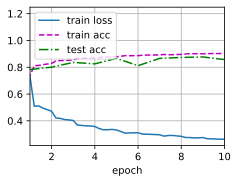

In [17]:
lr, num_epochs, batch_size = 1.0, 10, 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, torch.device('mps'))

In [18]:
net[1].gamma.reshape((-1,)), net[1].beta.reshape((-1,))

(tensor([2.7845, 0.4356, 1.9744, 4.1287, 3.1329, 3.1533], device='mps:0',
        grad_fn=<ViewBackward0>),
 tensor([-3.1184, -0.5586, -2.3142,  2.1719,  1.7076, -1.8107], device='mps:0',
        grad_fn=<ViewBackward0>))

##### 7.5.3 简明实现

In [19]:
net = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5), nn.BatchNorm2d(6), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Conv2d(6, 16, kernel_size=5), nn.BatchNorm2d(16), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2), nn.Flatten(),
    nn.Linear(256, 120), nn.BatchNorm1d(120), nn.Sigmoid(),
    nn.Linear(120, 84), nn.BatchNorm1d(84), nn.Sigmoid(),
    nn.Linear(84, 10))

loss 0.208, train acc 0.921, test acc 0.811
51260.4 examples/sec on mps


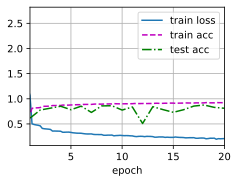

In [21]:
lr, num_epochs, batch_size = 4.0, 20, 1024
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, torch.device('mps'))

loss 0.180, train acc 0.933, test acc 0.872
50807.1 examples/sec on mps


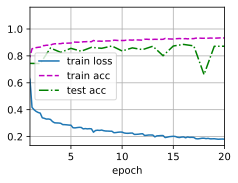

In [23]:
lr, num_epochs, batch_size = 0.4, 20, 1024
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, torch.device('mps'))

#### 7.6 残差网络（ResNet）
##### 7.6.1 函数类
优化目标：
$$f_F^*:=\argmin_f L(\mathbf{X},\mathbf{y},f),f\in F$$
残差网络的核心思想：**每个附加层都应该更容易地包含原始函数作为其元素之一**，由此诞生残差块（ResNet）

##### 7.6.2 残差块
在残差块中，输入课通过跨层数据通路更快地向前传播。

In [24]:
import torch
from torch import nn
from torch.nn import functional as F
from d2l import torch as d2l


class Residual(nn.Module):  #@save
    def __init__(self, input_channels, num_channels,
                 use_1x1conv=False, strides=1):
        super().__init__()
        self.conv1 = nn.Conv2d(input_channels, num_channels,
                               kernel_size=3, padding=1, stride=strides)
        self.conv2 = nn.Conv2d(num_channels, num_channels,
                               kernel_size=3, padding=1)
        if use_1x1conv:
            self.conv3 = nn.Conv2d(input_channels, num_channels,
                                   kernel_size=1, stride=strides)
        else:
            self.conv3 = None
        self.bn1 = nn.BatchNorm2d(num_channels)
        self.bn2 = nn.BatchNorm2d(num_channels)

    def forward(self, X):
        Y = F.relu(self.bn1(self.conv1(X)))
        Y = self.bn2(self.conv2(Y))
        if self.conv3:
            X = self.conv3(X)
        Y += X
        return F.relu(Y)

In [25]:
blk = Residual(3, 3)
X = torch.rand(4, 3, 6, 6)
Y = blk(X)
Y.shape

torch.Size([4, 3, 6, 6])

##### 7.6.3 ResNet模型

In [26]:
b1 = nn.Sequential(nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3),
                   nn.BatchNorm2d(64), nn.ReLU(),
                   nn.MaxPool2d(kernel_size=3, stride=2, padding=1))
def resnet_block(input_channels, num_channels, num_residuals,
                 first_block=False):
    blk = []
    for i in range(num_residuals):
        if i == 0 and not first_block:
            blk.append(Residual(input_channels, num_channels,
                                use_1x1conv=True, strides=2))
        else:
            blk.append(Residual(num_channels, num_channels))
    return blk
b2 = nn.Sequential(*resnet_block(64, 64, 2, first_block=True))
b3 = nn.Sequential(*resnet_block(64, 128, 2))
b4 = nn.Sequential(*resnet_block(128, 256, 2))
b5 = nn.Sequential(*resnet_block(256, 512, 2))
net = nn.Sequential(b1, b2, b3, b4, b5,
                    nn.AdaptiveAvgPool2d((1,1)),
                    nn.Flatten(), nn.Linear(512, 10))

In [27]:
X = torch.rand(size=(1, 1, 224, 224))
for layer in net:
    X = layer(X)
    print(layer.__class__.__name__,'output shape:\t', X.shape)

Sequential output shape:	 torch.Size([1, 64, 56, 56])
Sequential output shape:	 torch.Size([1, 64, 56, 56])
Sequential output shape:	 torch.Size([1, 128, 28, 28])
Sequential output shape:	 torch.Size([1, 256, 14, 14])
Sequential output shape:	 torch.Size([1, 512, 7, 7])
AdaptiveAvgPool2d output shape:	 torch.Size([1, 512, 1, 1])
Flatten output shape:	 torch.Size([1, 512])
Linear output shape:	 torch.Size([1, 10])


loss 0.014, train acc 0.996, test acc 0.916
3631.3 examples/sec on mps


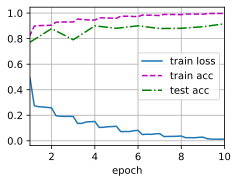

In [28]:
lr, num_epochs, batch_size = 0.05, 10, 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size, resize=96)
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, torch.device('mps'))

loss 0.011, train acc 0.998, test acc 0.921
3755.7 examples/sec on mps


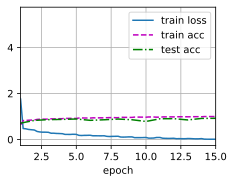

In [29]:
lr, num_epochs, batch_size = 0.2, 15, 1024
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size, resize=96)
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, torch.device('mps'))

#### 7.7 稠密连接网络（DenseNet）
##### 7.7.1 从ResNet到DenseNet
由泰勒展开式：
$$f(x)=f(x)+f'(0)x+\frac{f''(0)}{2!}x^2+\frac{f'''(0)}{3!}x^3+\cdot\cdot\cdot$$
- ResNet可将函数展开为：
$$f(\mathbf{x})=\mathbf{x}+g(\mathbf{x})$$
分解为一个简单线性项和一个复杂非线性项。
- DenseNet输出为**连接**：
$$\mathbf{x}\rightarrow[\mathbf{x},f_1(\mathbf{x}),f_2([\mathbf{x},f_1(\mathbf{x})]),\cdot\cdot\cdot]$$
稠密网络由**稠密块（Dense Block）**和**过渡层（Transition Layer）**组成，前者定义输入输出的连接方式，后者控制通道数。

##### 7.7.2 稠密块体

In [4]:
import torch
from torch import nn
from d2l import torch as d2l

def conv_block(input_channels, num_channels):
    return nn.Sequential(
        nn.BatchNorm2d(input_channels,), nn.ReLU(),
        nn.Conv2d(input_channels, num_channels, kernel_size=3, padding=1)
    )

In [2]:
class DenseBlock(nn.Module):
    def __init__(self, num_convs, input_channels, num_channels):
        super(DenseBlock, self).__init__()
        layer = []
        for i in range(num_convs):
            layer.append(conv_block(
                num_channels * i + input_channels, num_channels))
        self.net = nn.Sequential(*layer)
    def forward(self, X):
        for blk in self.net:
            Y = blk(X)
            X = torch.cat((X, Y), dim=1)
        return X

In [5]:
blk = DenseBlock(2, 3, 10)
X = torch.randn(4, 3, 8, 8)
Y = blk(X)
Y.shape

torch.Size([4, 23, 8, 8])

##### 7.7.3 过渡层
过渡层通过1×1卷积层来减小通道数，并使用平均步幅为2的平均汇聚层减半高度和宽度，进一步降低模型复杂度。

In [6]:
def transition_block(input_channels, num_channels):
    return nn.Sequential(
        nn.BatchNorm2d(input_channels), nn.ReLU(),
        nn.Conv2d(input_channels, num_channels, kernel_size=1),
        nn.AvgPool2d(kernel_size=2, stride=2))

In [8]:
blk = transition_block(23, 10)
blk(Y).shape
torch.Size([4, 10, 4, 4])

torch.Size([4, 10, 4, 4])

##### 7.7.4 DenseNet模型

In [10]:
b1 = nn.Sequential(
    nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3),
    nn.BatchNorm2d(64), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

In [11]:
num_channels, growth_rate = 64, 32
num_convs_in_dense_block = [4, 4, 4, 4]
blks = []
for i, num_convs in enumerate(num_convs_in_dense_block):
    blks.append(DenseBlock(num_convs, num_channels, growth_rate))
    num_channels += num_convs * growth_rate
    if i != len(num_convs_in_dense_block) - 1:
        blks.append(transition_block(num_channels, num_channels//2))
        num_channels = num_channels // 2
net = nn.Sequential(
    b1, *blks, 
    nn.BatchNorm2d(num_channels), nn.ReLU(),
    nn.AdaptiveAvgPool2d((1, 1)),
    nn.Flatten(),
    nn.Linear(num_channels, 10))

##### 7.7.5 训练模型

loss 0.140, train acc 0.949, test acc 0.804
2334.1 examples/sec on mps


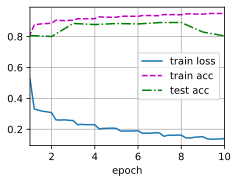

In [13]:
lr, num_epochs, batch_size = 0.1, 10, 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size, resize=96)
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, torch.device('mps'))

loss 0.139, train acc 0.948, test acc 0.809
7564.5 examples/sec on mps


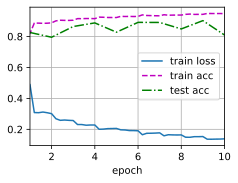

In [14]:
lr, num_epochs, batch_size = 0.1, 10, 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size, resize=48)
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, torch.device('mps'))

loss 0.164, train acc 0.938, test acc 0.895
10761.6 examples/sec on mps


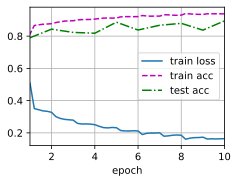

In [16]:
lr, num_epochs, batch_size = 0.1, 10, 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size, resize=36)
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, torch.device('mps'))

loss 0.364, train acc 0.862, test acc 0.849
13855.5 examples/sec on mps


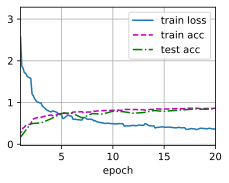

In [23]:
lr, num_epochs, batch_size = 0.8, 20, 8192
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size, resize=36)
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, torch.device('mps'))